Run 1/10 complete.
Run 2/10 complete.
Run 3/10 complete.
Run 4/10 complete.
Run 5/10 complete.
Run 6/10 complete.
Run 7/10 complete.
Run 8/10 complete.
Run 9/10 complete.
Run 10/10 complete.

--- FAIR DISTRICTS ---
 Run  Party 0  Party 1  Party 2
   1   0.0368   0.3598   0.2420
   2   0.0858   0.3140   0.2420
   3   0.0840   0.3144   0.2420
   4   0.0912   0.3072   0.2420
   5   0.0368   0.3598   0.2420
   6   0.0368   0.3598   0.2420
   7   0.0374   0.3598   0.2414
   8   0.1024   0.2990   0.2420
   9   0.0988   0.3010   0.2420
  10   0.0368   0.3598   0.2420

--- FAIR MEAN ---
Party 0    0.06468
Party 1    0.33346
Party 2    0.24194
dtype: float64

--- GERRYMANDERED DISTRICTS ---
 Run  Party 0  Party 1  Party 2
   1   0.1084   0.2920   0.2420
   2   0.0368   0.3598   0.2420
   3   0.0368   0.3598   0.2420
   4   0.0912   0.3068   0.2420
   5   0.0842   0.3132   0.2420
   6   0.0850   0.3118   0.2420
   7   0.0368   0.3598   0.2420
   8   0.0368   0.3598   0.2420
   9   0.0852   0.312

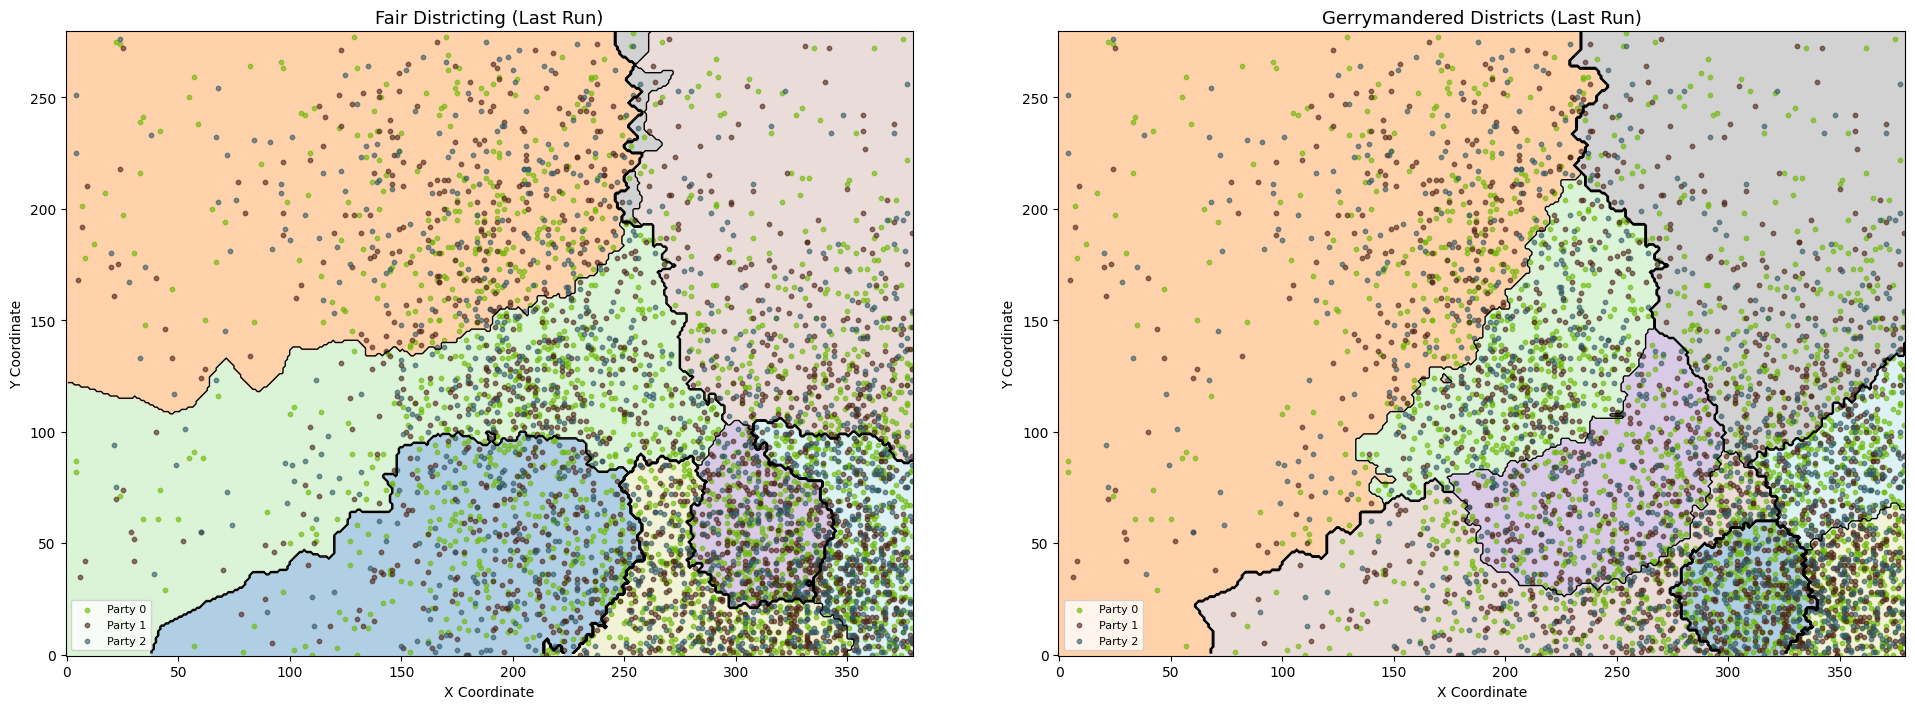

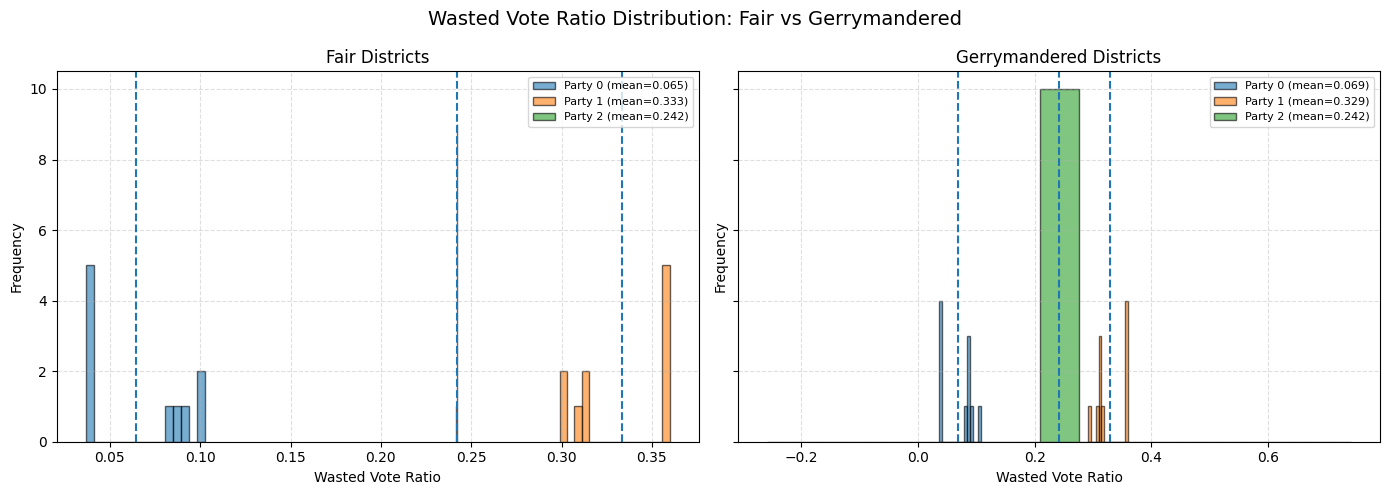

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from collections import deque
import pandas as pd
import itertools

# ------------------------
# PARAMETERS
# ------------------------
WIDTH = 380
HEIGHT = 280
NUM_VOTERS = 5000
NUM_PARTIES = 3
NUM_DISTRICTS = 8
VOTERS_PER_DISTRICT = NUM_VOTERS // NUM_DISTRICTS
NUM_RUNS = 10 

NUM_CITIES = 8
CITY_INTENSITY = (10, 30)
CITY_SPREAD = (20, 60)

np.random.seed(1)

PARTY_IDS = [f"Party {i}" for i in range(NUM_PARTIES)]
party_colors = np.random.rand(NUM_PARTIES, 3)
PARTY_COLORS = dict(zip(PARTY_IDS, party_colors))

PARTY_BIAS = [0.40, 0.35, 0.25]

# ------------------------
# GENERATE DENSITY FIELD
# ------------------------
density = np.full((HEIGHT, WIDTH), 1.0)
X, Y = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))


for _ in range(NUM_CITIES):
    cx = np.random.uniform(0, WIDTH)
    cy = np.random.uniform(0, HEIGHT)
    intensity = np.random.uniform(*CITY_INTENSITY)
    sigma = np.random.uniform(*CITY_SPREAD)
    density += intensity * np.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))

flat_density = density.ravel()
flat_density /= flat_density.sum()

indices = np.random.choice(WIDTH * HEIGHT, size=NUM_VOTERS, p=flat_density)
voters_y, voters_x = np.unravel_index(indices, (HEIGHT, WIDTH))
voters = np.column_stack((voters_x, voters_y))

# ------------------------
# PARTY ASSIGNMENT
# ------------------------
voter_parties = np.random.choice(
    np.arange(NUM_PARTIES),
    size=NUM_VOTERS,
    p=PARTY_BIAS
)

# ------------------------
# ADJACENCY GRAPH (kNN)
# Built once and frozen — defines all legal expansion moves
# ------------------------
def build_adjacency(voters, k=40):
    tree = cKDTree(voters)
    adjacency = {}
    for i in range(len(voters)):
        _, idx = tree.query(voters[i], k=k+1)
        adjacency[i] = set(idx[1:])
    return adjacency

adjacency = build_adjacency(voters, k=40)

# ------------------------
# SEED SELECTION
# Seeds are spread out using a minimum distance constraint
# to prevent two seeds landing near each other, which causes
# one district to fill a small area and leave isolated pockets
# ------------------------
def pick_seeds(n_nodes, num_districts, rng, voters, min_dist=40):
    seeds = []
    attempts = 0
    max_attempts = n_nodes * 10

    while len(seeds) < num_districts and attempts < max_attempts:
        candidate = rng.integers(n_nodes)
        attempts += 1

        if not seeds:
            seeds.append(candidate)
            continue

        # Enforce minimum spatial distance between seeds
        seed_coords = voters[seeds]
        candidate_coord = voters[candidate]
        dists = np.linalg.norm(seed_coords - candidate_coord, axis=1)

        if dists.min() >= min_dist:
            seeds.append(candidate)

    # If not enough seeds found with spacing, fill remainder randomly
    if len(seeds) < num_districts:
        remaining = [i for i in range(n_nodes) if i not in seeds]
        rng.shuffle(remaining)
        seeds += remaining[:num_districts - len(seeds)]

    return np.array(seeds)

# ------------------------
# CONNECTED DISTRICT GROWTH (BFS)
# ------------------------
def grow_district(seed, adjacency, assigned, max_size, rng,
                  voter_parties=None, target_party=None, bias_strength=0.0):

    district = set([seed])
    queue = deque([seed])
    visited = set([seed])

    while queue and len(district) < max_size:
        node = queue.popleft()
        neighbors = list(adjacency[node])

        if target_party is not None and bias_strength > 0:
            def score(nbr):
                is_target = (voter_parties[nbr] == target_party)
                return bias_strength * is_target + (1 - bias_strength) * rng.random()
            neighbors = sorted(neighbors, key=score, reverse=True)
        else:
            rng.shuffle(neighbors)

        for nbr in neighbors:
            if nbr not in visited and not assigned[nbr]:
                visited.add(nbr)
                district.add(nbr)
                queue.append(nbr)
                if len(district) >= max_size:
                    break

    for n in district:
        assigned[n] = True

    return district

# ------------------------
# LEFTOVER ASSIGNMENT
# Iterative flood-fill along adjacency edges only.
# A voter can only join a district it is spatially touching,
# enforcing contiguity. Multiple passes handle voters whose
# neighbors were also unassigned on the previous pass.
# ------------------------
def assign_leftovers(districts, assigned, adjacency, labels, rng, max_iter=50):
    unassigned = [i for i in range(len(assigned)) if not assigned[i]]

    for _ in range(max_iter):
        if not unassigned:
            break

        still_unassigned = []

        for node in unassigned:
            # Only consider adjacency neighbors that are already assigned
            assigned_neighbors = [nbr for nbr in adjacency[node] if assigned[nbr]]

            if assigned_neighbors:
                neighbor_labels = [labels[nbr] for nbr in assigned_neighbors]
                chosen = max(set(neighbor_labels), key=neighbor_labels.count)
                districts[chosen].add(node)
                labels[node] = chosen
                assigned[node] = True
            else:
                still_unassigned.append(node)

        unassigned = still_unassigned

    # Safety net: if any voters remain unassigned after max_iter passes, assign them
    if unassigned:
        assigned_indices = np.where(assigned)[0]
        assigned_tree = cKDTree(voters[assigned_indices])
        for node in unassigned:
            _, idx = assigned_tree.query(voters[node])
            chosen = labels[assigned_indices[idx]]
            districts[chosen].add(node)
            labels[node] = chosen
            assigned[node] = True

    return districts, labels

# ------------------------
# MAIN DISTRICTING FUNCTION
# ------------------------
def connected_districts(voters, adjacency, num_districts, rng,
                        voter_parties, target_size=None, tolerance=0.15,
                        target_party=None, bias_strength=0.0):

    n = len(voters)
    if target_size is None:
        target_size = n // num_districts

    seeds = pick_seeds(n, num_districts, rng, voters, min_dist=40)

    assigned = np.zeros(n, dtype=bool)
    labels   = np.full(n, -1, dtype=int)
    districts = []

    for seed in seeds:

    # If this seed was absorbed by an earlier district, find
    # the nearest unassigned voter to use as a replacement
        if assigned[seed]:
            unassigned_pool = np.where(~assigned)[0]
            if len(unassigned_pool) == 0:
                break
        # Pick the spatially nearest unassigned voter to the
        # original seed location so the district still starts
        # in roughly the right part of the map
            dists = np.linalg.norm(voters[unassigned_pool] - voters[seed], axis=1)
            seed = unassigned_pool[np.argmin(dists)]

        district = grow_district(
            seed, adjacency, assigned, target_size, rng,
            voter_parties=voter_parties,
            target_party=target_party,
            bias_strength=bias_strength
        )
        d_id = len(districts)
        districts.append(district)
        for node in district:
            labels[node] = d_id

    # Fix disconnected leftovers with iterative adjacency flood-fill
    districts, labels = assign_leftovers(
        districts, assigned, adjacency, labels, rng
    )

    return labels

# ------------------------
# VOTE COUNTING
# ------------------------
def count_votes(district_labels, voter_parties):
    districts = [{party: 0 for party in PARTY_IDS} for _ in range(NUM_DISTRICTS)]
    for i, d in enumerate(district_labels):
        party = PARTY_IDS[voter_parties[i]]
        districts[d][party] += 1
    return districts

# ------------------------
# VISUALIZATION
# ------------------------
def plot_districts(district_labels, voter_parties, title):
    tree = cKDTree(voters)
    xx, yy = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))
    grid_points = np.column_stack((xx.ravel(), yy.ravel()))

    _, nearest_voter = tree.query(grid_points)
    pixel_districts = district_labels[nearest_voter]
    pixel_map = pixel_districts.reshape((HEIGHT, WIDTH))

    plt.figure(figsize=(10, 7))
    plt.imshow(pixel_map, origin='lower', cmap='tab20', alpha=0.35)
    plt.contour(
        pixel_map,
        levels=np.arange(NUM_DISTRICTS) + 0.5,
        colors='black',
        linewidths=1,
        origin='lower'
    )

    for i, party in enumerate(PARTY_IDS):
        mask = voter_parties == i
        plt.scatter(
            voters[mask, 0], voters[mask, 1],
            color=PARTY_COLORS[party], label=party, s=10, alpha=0.6
        )

    plt.title(title)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.legend()
    plt.tight_layout()
    plt.show()
# ============================================================
# SEAT-VOTE CURVE HELPERS
# ============================================================

def get_is_winner(district, target_party):
    target_votes = district[target_party]
    return all(target_votes > district[p] for p in district if p != target_party)

def get_current_vote_share(district_counts, target_party):
    total       = sum(sum(d.values()) for d in district_counts)
    party_total = sum(d[target_party] for d in district_counts)
    return party_total / total

def simulate_vote_shifts_forward(district_counts, target_party):
    counts      = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    n_comp      = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            active = sorted([p for p in competitors if d[p] > 0],
                            key=lambda p: (d[p], p))
            if active:
                taken = min(d[active[0]], n_comp)
                if taken > 0:
                    d[active[0]]    -= taken
                    d[target_party] += taken
                    any_shift = True

        new_wins = count_wins()
        if new_wins > current_wins:
            vs = (sum(d[target_party] for d in counts) /
                  sum(sum(d.values()) for d in counts))
            history.append({"districts_won": new_wins, "vote_share": vs})
            current_wins = new_wins

        if not any_shift or new_wins == NUM_DISTRICTS:
            break

    return history

def simulate_vote_shifts_backward(district_counts, target_party):
    counts      = [d.copy() for d in district_counts]
    competitors = [p for p in PARTY_IDS if p != target_party]
    n_comp      = len(competitors)

    def count_wins():
        return sum(1 for d in counts if get_is_winner(d, target_party))

    current_wins = count_wins()
    history = []

    while True:
        any_shift = False
        for d in counts:
            ranked  = sorted(competitors, key=lambda p: (d[p], p), reverse=True)
            to_move = min(d[target_party], n_comp)
            if to_move > 0:
                d[target_party] -= to_move
                d[ranked[0]]    += to_move
                any_shift = True

        new_wins = count_wins()
        if new_wins < current_wins:
            vs = (sum(d[target_party] for d in counts) /
                  sum(sum(d.values()) for d in counts))
            history.append({"districts_won": new_wins, "vote_share": vs})
            current_wins = new_wins

        if not any_shift or new_wins == 0:
            break

    return history

def compute_step_curve_for_party(district_counts, target_party):
    base = (get_current_vote_share(district_counts, target_party),
            sum(1 for d in district_counts if get_is_winner(d, target_party)))

    fwd = simulate_vote_shifts_forward(district_counts, target_party)
    rev = simulate_vote_shifts_backward(district_counts, target_party)

    pts = ([base]
           + [(h["vote_share"], h["districts_won"]) for h in fwd]
           + [(h["vote_share"], h["districts_won"]) for h in rev])
    return sorted(set(pts))

def compute_pairwise_area(curve1, curve2):
    x1, y1 = zip(*sorted(curve1))
    x2, y2 = zip(*sorted(curve2))
    y1 = np.array(y1) / NUM_DISTRICTS
    y2 = np.array(y2) / NUM_DISTRICTS

    all_x = np.unique(np.concatenate([x1, x2]))
    if all_x[0]  > 0: all_x = np.insert(all_x, 0, 0.0)
    if all_x[-1] < 1: all_x = np.append(all_x, 1.0)

    def get_val(x, xs, ys):
        return ys[max(0, np.searchsorted(xs, x, side='right') - 1)]

    area = 0.0
    for i in range(len(all_x) - 1):
        mid   = (all_x[i] + all_x[i+1]) / 2
        width = all_x[i+1] - all_x[i]
        area += width * abs(get_val(mid, x1, y1) - get_val(mid, x2, y2))
    return area
# ------------------------
# SIMULATION
# ------------------------
fair_wasted_vote_table  = []
gerry_wasted_vote_table = []
all_fair_counts  = []
all_gerry_counts = []
all_fair_step_curves  = []
all_gerry_step_curves = []
all_fair_pair_rows    = []
all_gerry_pair_rows   = []


party_pairs = list(itertools.combinations(PARTY_IDS, 2))

for run in range(NUM_RUNS):
    rng = np.random.default_rng(run)

    # ── FAIR ──────────────────────────────────────────────
    fair_labels = connected_districts(
        voters, adjacency, NUM_DISTRICTS, rng,
        voter_parties=voter_parties,
        target_size=VOTERS_PER_DISTRICT,
        tolerance=0.15
    )
    fair_counts = count_votes(fair_labels, voter_parties)
    all_fair_counts.append(fair_counts)

    fair_wasted_votes = {p: 0 for p in PARTY_IDS}
    total_votes = 0

    for district in fair_counts:
        district_total = sum(district.values())
        total_votes += district_total

        winner       = max(district, key=district.get)
        winner_votes = district[winner]
        next_highest = max(v for p, v in district.items() if p != winner)
        excess       = winner_votes - (next_highest + 1)

        for p in PARTY_IDS:
            fair_wasted_votes[p] += excess if p == winner else district[p]

    fair_row = {"Run": run + 1}
    fair_row.update({p: fair_wasted_votes[p] / total_votes for p in PARTY_IDS})
    fair_wasted_vote_table.append(fair_row)
    

    # ── GERRYMANDERED ─────────────────────────────────────
    # bias_strength capped at 0.75 to prevent BFS leaping
    # across the map and creating isolated pockets
    biased_labels = connected_districts(
        voters, adjacency, NUM_DISTRICTS, rng,
        voter_parties=voter_parties,
        target_size=VOTERS_PER_DISTRICT,
        tolerance=0.15,
        target_party=1,
        bias_strength=0.90
    )
    gerry_counts = count_votes(biased_labels, voter_parties)
    all_gerry_counts.append(gerry_counts)
    gerry_wasted_votes = {p: 0 for p in PARTY_IDS}
    total_votes = 0

    for district in gerry_counts:
        district_total = sum(district.values())
        total_votes += district_total

        winner       = max(district, key=district.get)
        winner_votes = district[winner]
        next_highest = max(v for p, v in district.items() if p != winner)
        excess       = winner_votes - (next_highest + 1)

        for p in PARTY_IDS:
            gerry_wasted_votes[p] += excess if p == winner else district[p]

    gerry_row = {"Run": run + 1}
    gerry_row.update({p: gerry_wasted_votes[p] / total_votes for p in PARTY_IDS})
    gerry_wasted_vote_table.append(gerry_row)

    # ── STEP CURVES ───────────────────────────────────────
    fair_curves  = {p: compute_step_curve_for_party(fair_counts,  p) for p in PARTY_IDS}
    gerry_curves = {p: compute_step_curve_for_party(gerry_counts, p) for p in PARTY_IDS}

    all_fair_step_curves.append(fair_curves)
    all_gerry_step_curves.append(gerry_curves)

    for p1, p2 in party_pairs:
        all_fair_pair_rows.append({
            "Run": run + 1, "Comparison": f"{p1} vs {p2}",
            "Pairwise_Area": compute_pairwise_area(fair_curves[p1],  fair_curves[p2])
        })
        all_gerry_pair_rows.append({
            "Run": run + 1, "Comparison": f"{p1} vs {p2}",
            "Pairwise_Area": compute_pairwise_area(gerry_curves[p1], gerry_curves[p2])
        })
    print(f"Run {run + 1}/{NUM_RUNS} complete.")

# ------------------------
# RESULTS
# ------------------------
df_fair  = pd.DataFrame(fair_wasted_vote_table)
df_gerry = pd.DataFrame(gerry_wasted_vote_table)

print("\n--- FAIR DISTRICTS ---")
print(df_fair.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n--- FAIR MEAN ---")
print(df_fair.drop(columns="Run").mean())

print("\n--- GERRYMANDERED DISTRICTS ---")
print(df_gerry.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("\n--- GERRYMANDERED MEAN ---")
print(df_gerry.drop(columns="Run").mean())

# ------------------------
# VISUALIZE LAST RUN
# ------------------------
#plot_districts(fair_labels,   voter_parties, "Fair Districting (Last Run)")
#plot_districts(biased_labels, voter_parties, "Gerrymandered Districts (Last Run)")

# ------------------------
# VISUALIZE LAST RUN — SIDE BY SIDE
# ------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

def plot_districts_ax(ax, district_labels, voter_parties, title):
    tree = cKDTree(voters)
    xx, yy = np.meshgrid(np.arange(WIDTH), np.arange(HEIGHT))
    grid_points = np.column_stack((xx.ravel(), yy.ravel()))

    _, nearest_voter = tree.query(grid_points)
    pixel_districts = district_labels[nearest_voter]
    pixel_map = pixel_districts.reshape((HEIGHT, WIDTH))

    ax.imshow(pixel_map, origin='lower', cmap='tab20', alpha=0.35)
    ax.contour(
        pixel_map,
        levels=np.arange(NUM_DISTRICTS) + 0.5,
        colors='black',
        linewidths=1,
        origin='lower'
    )
    for i, party in enumerate(PARTY_IDS):
        mask = voter_parties == i
        ax.scatter(
            voters[mask, 0], voters[mask, 1],
            color=PARTY_COLORS[party], label=party, s=10, alpha=0.6
        )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("X Coordinate")
    ax.set_ylabel("Y Coordinate")
    ax.legend(fontsize=8)

plot_districts_ax(axes[0], fair_labels,   voter_parties, "Fair Districting (Last Run)")
plot_districts_ax(axes[1], biased_labels, voter_parties, "Gerrymandered Districts (Last Run)")

plt.tight_layout()
plt.show()

# ------------------------
# HISTOGRAMS: Wasted Vote Ratios
# ------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Wasted Vote Ratio Distribution: Fair vs Gerrymandered", fontsize=14)

for ax, df, color, title in zip(
    axes,
    [df_fair, df_gerry],
    ["steelblue", "tomato"],
    ["Fair Districts", "Gerrymandered Districts"]
):
    for party in PARTY_IDS:
        mean_val = df[party].mean()
        ax.hist(df[party], bins=15, alpha=0.6, edgecolor="black",
                label=f"{party} (mean={mean_val:.3f})")
        ax.axvline(mean_val, linestyle="--", lw=1.5)

    ax.set_title(title)
    ax.set_xlabel("Wasted Vote Ratio")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [8]:
# ------------------------
# DISTRICT WINNERS PER RUN
# ------------------------
fair_winner_rows  = []
gerry_winner_rows = []

for run_idx in range(NUM_RUNS):
    fair_row  = {"Run": run_idx + 1}
    gerry_row = {"Run": run_idx + 1}

    for d_idx, (fc, gc) in enumerate(zip(all_fair_counts[run_idx], all_gerry_counts[run_idx])):
        fair_row [f"District {d_idx}"] = max(fc, key=fc.get)
        gerry_row[f"District {d_idx}"] = max(gc, key=gc.get)

    fair_winner_rows.append(fair_row)
    gerry_winner_rows.append(gerry_row)

df_fair_winners  = pd.DataFrame(fair_winner_rows)
df_gerry_winners = pd.DataFrame(gerry_winner_rows)

print("\n--- FAIR MAP: District Winners per Run ---")
print(df_fair_winners.to_string(index=False))

print("\n--- GERRYMANDERED MAP: District Winners per Run ---")
print(df_gerry_winners.to_string(index=False))


--- FAIR MAP: District Winners per Run ---
 Run District 0 District 1 District 2 District 3 District 4 District 5 District 6 District 7
   1    Party 0    Party 0    Party 0    Party 0    Party 0    Party 0    Party 0    Party 0
   2    Party 0    Party 1    Party 0    Party 0    Party 0    Party 0    Party 0    Party 0
   3    Party 0    Party 0    Party 0    Party 0    Party 0    Party 1    Party 0    Party 0
   4    Party 0    Party 0    Party 1    Party 0    Party 0    Party 0    Party 0    Party 0
   5    Party 0    Party 0    Party 0    Party 0    Party 0    Party 0    Party 0    Party 0
   6    Party 0    Party 0    Party 0    Party 0    Party 0    Party 0    Party 0    Party 0
   7    Party 0    Party 0    Party 0    Party 0    Party 0    Party 0    Party 0    Party 2
   8    Party 0    Party 0    Party 0    Party 1    Party 0    Party 0    Party 0    Party 1
   9    Party 0    Party 0    Party 1    Party 0    Party 0    Party 0    Party 0    Party 1
  10    Party 0    Party 0


--- FAIR: Pairwise Partisan Symmetry ---
                        mean       std
Comparison                            
Party 0 vs Party 1  0.016517  0.002320
Party 0 vs Party 2  0.027603  0.005509
Party 1 vs Party 2  0.019285  0.005615

--- GERRYMANDERED: Pairwise Partisan Symmetry ---
                        mean       std
Comparison                            
Party 0 vs Party 1  0.017030  0.001665
Party 0 vs Party 2  0.030242  0.008558
Party 1 vs Party 2  0.019207  0.007475


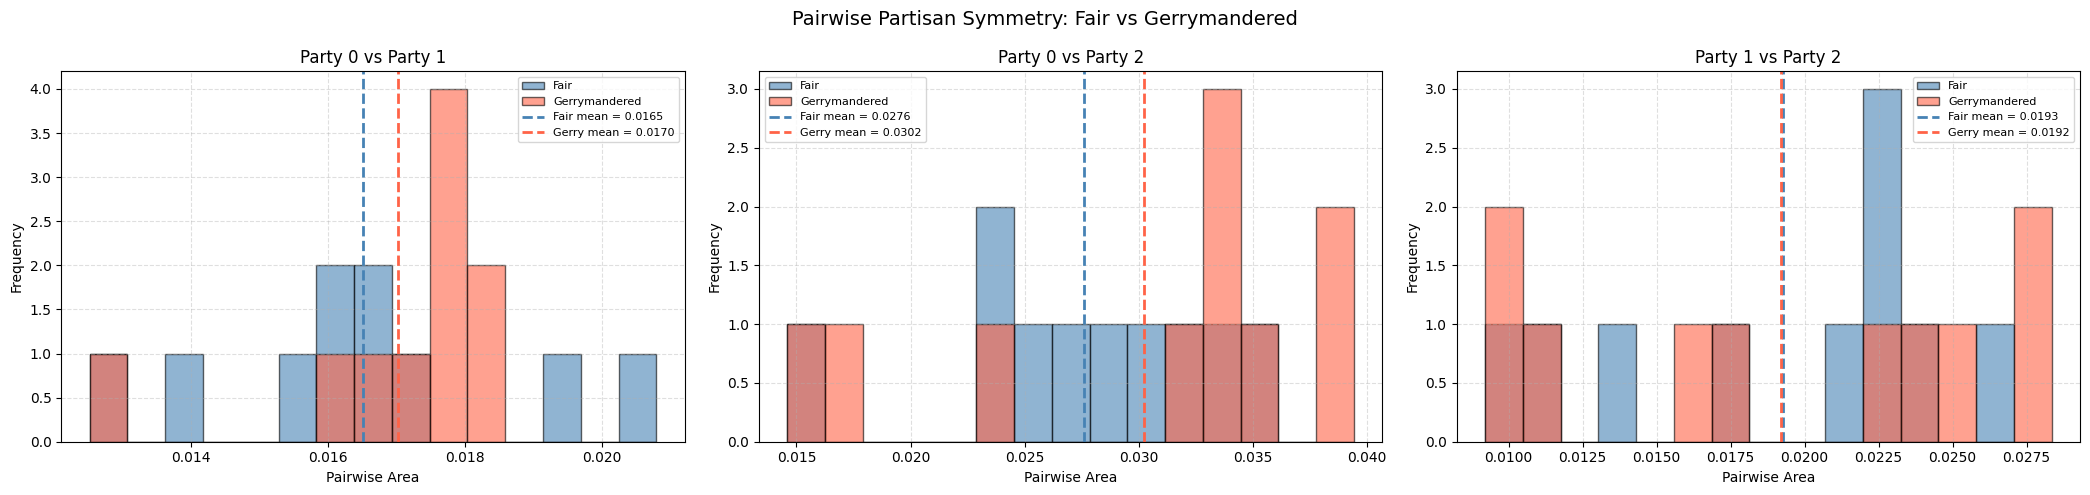

In [10]:
df_fair_pair  = pd.DataFrame(all_fair_pair_rows)
df_gerry_pair = pd.DataFrame(all_gerry_pair_rows)

print("\n--- FAIR: Pairwise Partisan Symmetry ---")
print(df_fair_pair.groupby("Comparison")["Pairwise_Area"].agg(["mean", "std"]))

print("\n--- GERRYMANDERED: Pairwise Partisan Symmetry ---")
print(df_gerry_pair.groupby("Comparison")["Pairwise_Area"].agg(["mean", "std"]))

n_pairs = len(party_pairs)
fig, axes = plt.subplots(1, n_pairs, figsize=(7 * n_pairs, 5))
if n_pairs == 1:
    axes = [axes]

fig.suptitle("Pairwise Partisan Symmetry: Fair vs Gerrymandered", fontsize=14)

for ax, (p1, p2) in zip(axes, party_pairs):
    comp       = f"{p1} vs {p2}"
    fair_vals  = df_fair_pair [df_fair_pair ["Comparison"] == comp]["Pairwise_Area"]
    gerry_vals = df_gerry_pair[df_gerry_pair["Comparison"] == comp]["Pairwise_Area"]

    bins = np.linspace(min(fair_vals.min(), gerry_vals.min()),
                       max(fair_vals.max(), gerry_vals.max()), 16)

    ax.hist(fair_vals,  bins=bins, alpha=0.6, color="steelblue",
            edgecolor="black", label="Fair")
    ax.hist(gerry_vals, bins=bins, alpha=0.6, color="tomato",
            edgecolor="black", label="Gerrymandered")
    ax.axvline(fair_vals.mean(),  color="steelblue", linestyle="--", lw=2,
               label=f"Fair mean = {fair_vals.mean():.4f}")
    ax.axvline(gerry_vals.mean(), color="tomato",    linestyle="--", lw=2,
               label=f"Gerry mean = {gerry_vals.mean():.4f}")
    ax.set_title(comp)
    ax.set_xlabel("Pairwise Area")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()